**To dos here:**
1. Code up negative binomial MCMC to obtain the $\ln \langle n_i(a,t)\rangle$ values for each species as above.
2. Code up fitting a Gaussian correlated posterior profile to the $\ln \langle n_i(a,t)\rangle$ posterior for each species. 
3. Get new data on species death rates and recreational freshwater angling!!!

In [1]:
import sys
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

path = "/home/robert/Code/anglerpol/"

sys.path.append(path)
from src.data.database import ecoDB
import src.data.gov_data_utils as datutils
import src.plotting.NFPD_fish_data as fishplots

**IMPORTANT Data information to be aware of:**

- The surveys seem to [usually be conducted with electrofishing](https://environmentagency.blog.gov.uk/2016/05/11/how-we-carry-out-fish-surveys/) - which actually avoids harming the fish so that they can return to their population.
- `'Is Species Selective'` - this survey was focussed on a particular subset of species and so should not be used to get a representative sample of the whole population.
- `'Survey method'` - each method is distinct and so will not only give different $k$ values for the negative binomial but also different means.

In [2]:
# Retrieve the fish counts data
edb = ecoDB(path)
edb.get_unzipped_files("NFPD_FWfish_counts")
df = pd.read_csv(
    path + "data/" + edb.unzipped_files["NFPD_FWfish_counts"][0]
)

Archive:  NFPD_FWfish_counts.zip
  inflating: FW_Fish_Counts.csv      


/home/robert/.local/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (15) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
df.LOCATION_NAME.unique()

array(['Anglian Central', 'Anglian Eastern (Kelvedon)',
       'Anglian Eastern (Norwich)', 'Anglian Northern (Kettering)',
       'Anglian Northern (Manby)', 'Midlands Central', 'Midlands East',
       'Midlands West', 'North East North East', 'North East Yorkshire',
       'North West North (Central)', 'North West North (North)',
       'North West South', 'South West Devon and Cornwall (Cornwall)',
       'South West Devon and Cornwall (Devon)',
       'South West Wessex (North - Bridgwater)',
       'South West Wessex (South - Blandford)',
       'Southern Kent and East Sussex', 'Southern Solent and South Downs',
       'Thames North East', 'Thames South East (London)',
       'Thames South East (Provincial)', 'Thames West'], dtype=object)

In [16]:
# Need to add a Trophic level indicator for each species here...
df.SPECIES_NAME.unique()

array(['Bleak', 'Bullhead', 'Chub', 'Common bream', 'Perch', 'Pike',
       'Roach', 'Tench', 'Silver bream', 'Spined loach', 'Gudgeon',
       'Roach x common bream hybrid', 'Ruffe', 'Dace',
       'European eels > elvers', '3-spined stickleback', 'Stone loach',
       'Bitterling', 'Minnow', 'Rudd', 'Zander', 'Common [wild] carp',
       'Mirror carp', 'Smelt', 'European eel', 'Bleak x roach hybrid',
       'Roach x rudd hybrid', '10-spined stickleback',
       'Roach x chub hybrid', 'Brown / sea trout', 'Brook lamprey',
       'Rainbow trout', 'Crucian carp', nan, 'Brook lamprey > ammocoete',
       'Flounder', 'River lamprey', 'River lamprey > ammocoete',
       'Grass carp', 'Common carp varieties', 'Barbel', 'Orfe / Ide',
       'Golden tench', 'Feral [brown] goldfish', 'Golden rudd',
       'Roach x silver bream hybrid', 'Dace x bleak hybrid',
       'Common bream x silver bream hybrid', 'Brook lamprey ammocoetes',
       'Grayling', 'Sea lamprey', 'Rudd x common bream hybrid',


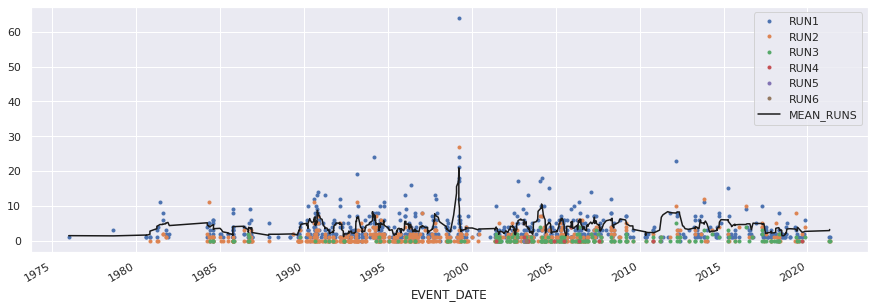

In [7]:
# This would have a nice negative binomial fit I'm guessing...
maskd = {
    'LOCATION_NAME' : ['Midlands Central'],
    'SPECIES_NAME' : ['Pike'],
}
fishplots.plot_fish_counts(df, mask_dict=maskd)

In [5]:
edb = ecoDB(path)
edb.get_unzipped_files("NFPD_FWfish_banded_measurements")
df = pd.read_csv(
    path + "data/" + edb.unzipped_files["NFPD_FWfish_banded_measurements"][0]
)

Archive:  NFPD_FWfish_banded_measurements.zip
  inflating: FW_Fish_Banded_Measurements.csv  


In [6]:
df['INTERVAL_LENGTH_FISH_BAND'] = df.apply(
    lambda x: pd.Interval(x['BAND_LENGTH_START'], x['BAND_LENGTH_END']), 
    axis=1,
)

In [10]:
df

,SURVEY_ID,SURVEY_SPECIES_ID,SPECIES_ID,SPECIES_RUN_ID,RUN_NUMBER,BANDED_MEASURED_ID,BAND_LENGTH_START,BAND_LENGTH_END,BAND_FISH_COUNT,AGE_BAND,INTERVAL_LENGTH_FISH_BAND
0,118790,451501,283,591764,1,163988,75,79,1,NaN,"(75, 79]"
1,118790,451501,283,591765,2,164039,75,79,1,NaN,"(75, 79]"
2,118790,451502,181,591766,1,163989,65,69,1,NaN,"(65, 69]"
3,118790,451502,181,591766,1,163990,70,74,8,NaN,"(70, 74]"
4,118790,451502,181,591766,1,163991,75,79,11,NaN,"(75, 79]"
...,...,...,...,...,...,...,...,...,...,...,...
198473,101100,368921,111,452195,3,95415,60,64,1,0+,"(60, 64]"
198474,101100,368921,111,452195,3,95416,65,69,2,0+,"(65, 69]"
198475,101100,368921,111,452195,3,95417,70,74,1,0+,"(70, 74]"
198476,101100,368921,111,452195,3,95418,75,79,1,0+,"(75, 79]"


In [12]:
edb = ecoDB(path)
edb.get_unzipped_files("NFPD_FWfish_bulk_measurements")
df = pd.read_csv(
    path + "data/" + edb.unzipped_files["NFPD_FWfish_bulk_measurements"][0]
)

Archive:  NFPD_FWfish_bulk_measurements.zip
  inflating: FW_Fish_Bulk_Measurements.csv  


In [13]:
df

,SURVEY_ID,SURVEY_SPECIES_ID,SPECIES_ID,SPECIES_RUN_ID,RUN_NUMBER,BULK_MEASURED_ID,BULK_LENGTH_START,BULK_LENGTH_END,BULK_FISH_COUNT,BULK_FISH_WEIGHT,AGE_BAND
0,29322,99127,242,94882,1,13924,NaN,NaN,26,5900.0,NaN
1,29322,99127,242,94883,2,13925,NaN,NaN,11,1800.0,NaN
2,29336,99211,194,95019,1,13934,43.0,263.0,6335,NaN,NaN
3,29336,99211,194,95020,2,13938,53.0,233.0,363,NaN,NaN
4,29336,99214,211,95024,1,13935,53.0,153.0,369,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
63838,160417,711037,111,943265,1,204628,53.0,85.0,15,NaN,0+
63839,88126,308083,118,379995,1,69544,50.0,84.0,37,NaN,0+
63840,103087,378841,118,470040,1,108872,55.0,94.0,26,NaN,0+
63841,120473,459212,118,605692,1,140866,50.0,74.0,127,NaN,0+


In [3]:
edb = ecoDB(path)
edb.get_unzipped_files("Biosys_FWriver_macroinvertebrates")
df = pd.read_csv(
    path + "data/" + edb.unzipped_files["Biosys_FWriver_macroinvertebrates"][0]
)

Archive:  Biosys_FWriver_macroinvertebrates.zip
  inflating: INV_OPEN_DATA_SITE.csv  
  inflating: INV_OPEN_DATA_METRICS.csv  
  inflating: INV_OPEN_DATA_TAXA.csv  


/home/robert/.local/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [6]:
df

,SITE_ID,SAMPLE_ID,SAMPLE_VERSION,REPLICATE_CODE,SAMPLE_DATE,SAMPLE_TYPE,SAMPLE_TYPE_DESCRIPTION,SAMPLE_METHOD,SAMPLE_METHOD_DESCRIPTION,SAMPLE_REASON,...,PSI_ABCD,PSI_FAMILY_SCORE,WHPT_N_TAXA,WHPT_TOTAL,WHPT_ASPT,WHPT_NW_N_TAXA,WHPT_NW_TOTAL,WHPT_NW_ASPT,IS_THIRD_PARTY_DATA,WATERBODY_TYPE
0,56182,167406,1,NaN,12/05/1989,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",Local monitoring,...,9.0,33.33,8.0,30.7,3.84,8.0,29.8,3.73,No,WBRV
1,56182,148952,1,NaN,23/04/1990,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",Local monitoring,...,7.0,14.29,4.0,10.5,2.63,4.0,14.4,3.60,No,WBRV
2,56182,149203,1,NaN,07/08/1990,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",Local monitoring,...,10.0,40.00,5.0,14.9,2.98,5.0,17.9,3.58,No,WBRV
3,56182,174807,1,NaN,04/10/1990,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",Local monitoring,...,12.0,16.67,7.0,22.6,3.23,7.0,21.2,3.03,No,WBRV
4,56182,149509,1,NaN,13/03/1991,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",Local monitoring,...,11.0,27.27,7.0,22.4,3.20,7.0,23.2,3.31,No,WBRV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263226,183645,783922,1,NaN,19/09/2018,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",National Monitoring,...,58.0,55.17,27.0,140.1,5.19,27.0,145.9,5.40,No,WBRV
263227,183645,794606,1,NaN,30/04/2019,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",National Monitoring,...,43.0,44.19,25.0,123.0,4.92,25.0,123.6,4.94,No,WBRV
263228,183645,800520,1,NaN,02/09/2019,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",National Monitoring,...,39.0,58.97,18.0,94.1,5.23,18.0,91.2,5.07,No,WBRV
263229,183645,816922,1,NaN,30/10/2020,SP,FRESHWATER: INVERTEBRATE All macroinvertebrate...,S3PO,"3-MIN POND NET (BT001): 3-min active sampling,...",National Monitoring,...,47.0,65.96,23.0,126.7,5.51,23.0,122.9,5.34,No,WBRV
